**⚠️ Technical Note:** This notebook was developed in a Google Colab environment. The raw bioclimatic and GEDI/VHM datasets are hosted in a private Google Drive directory. To replicate this study, users must provide their own raster assets or contact the author for access to the standardized 1km² Parquet files.

# 03: Random Forest Calibration and SHAP
**Project:** A Validated Predictive Framework for Climate-Smart Reforestation in Armenia

**Author:** Narek Ohanyan

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap
import matplotlib.pyplot as plt
import joblib

In [ ]:
BASE_DIR = '/content/drive/MyDrive/FORACCA_Output_1_2'

In [ ]:
# --- Define Paths ---
PARQUET_PATH = f'{BASE_DIR}/data_processed/Armenia_ML_Training_Data.parquet'
MODEL_OUT_PATH = f'{BASE_DIR}/models/RF_FVS_Model.joblib'

print("1. Loading the Training Data...")
df = pd.read_parquet(PARQUET_PATH)

print("2. Defining Features (X) and Target (y)...")
# X: The Growing Season Climate Stressors
X = df[['Delta_VPD_GS', 'Delta_Tmax_GS', 'Delta_P_GS']]

# y: The Structural Complexity (Standard Deviation of Canopy Height)
# We use vhm_std because a collapsing canopy loses its vertical complexity
y = df['vhm_std']

print("3. Splitting into Train and Test sets...")
# We hold back 20% of the pixels to test the model's accuracy on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data loaded! Training on {len(X_train)} pixels, Testing on {len(X_test)} pixels.")

1. Loading the Training Data...
2. Defining Features (X) and Target (y)...
3. Splitting into Train and Test sets...
✅ Data loaded! Training on 3470 pixels, Testing on 868 pixels.


In [ ]:
print("1. Initializing the Random Forest Regressor...")
# We use 500 trees for a highly stable and rigorous model
rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)

print("2. Training the Model (Finding the Biological Thresholds)...")
rf_model.fit(X_train, y_train)

print("3. Evaluating Model Accuracy...")
# Ask the model to predict the structure for the 20% of pixels it has never seen
y_pred = rf_model.predict(X_test)

# Calculate how close the predictions are to reality
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"✅ Training Complete!")
print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.3f} meters")

print("\n4. Feature Importances (Which stressor matters most?):")
importances = rf_model.feature_importances_
for name, importance in zip(X.columns, importances):
    print(f" - {name}: {importance * 100:.1f}%")

1. Initializing the Random Forest Regressor...
2. Training the Model (Finding the Biological Thresholds)...
3. Evaluating Model Accuracy...
✅ Training Complete!
R² Score: 0.292
Mean Absolute Error: 1.799 meters

4. Feature Importances (Which stressor matters most?):
 - Delta_VPD_GS: 34.9%
 - Delta_Tmax_GS: 31.4%
 - Delta_P_GS: 33.7%


1. Initializing SHAP Tree Explainer...
2. Calculating SHAP values for the test data (This may take a minute)...
3. Generating the SHAP Summary Plot...


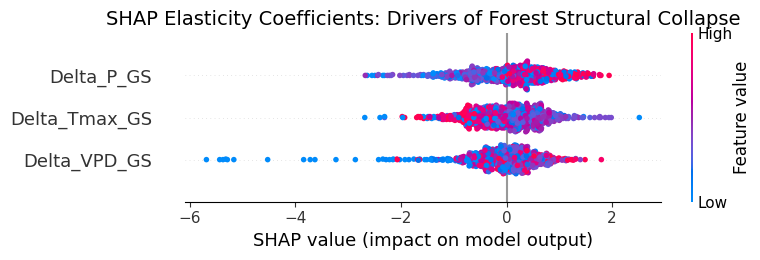

In [ ]:
print("1. Initializing SHAP Tree Explainer...")
# Explain the Random Forest's mathematical decisions
explainer = shap.TreeExplainer(rf_model)

print("2. Calculating SHAP values for the test data (This may take a minute)...")
shap_values = explainer.shap_values(X_test)

print("3. Generating the SHAP Summary Plot...")
# This plot will show the directional impact of each climate stressor
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Elasticity Coefficients: Drivers of Forest Structural Collapse", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("Saving the trained Random Forest model...")
# Export the 'brain' to your models folder
joblib.dump(rf_model, MODEL_OUT_PATH)

print(f"✅ Model successfully saved to: {MODEL_OUT_PATH}")
print("Notebook 03 is officially complete!")

Saving the trained Random Forest model...
✅ Model successfully saved to: /content/drive/MyDrive/FORACCA_Output_1_2/models/RF_FVS_Model.joblib
Notebook 03 is officially complete!
